# Прогнозирование систолического артериального давления в NHANES

**Задача.** Построить воспроизводимый пайплайн регрессии для SystolicBloodPressureMmHg (мм рт. ст.) из набора NHANES. Я сначала проверяю качество и структуру данных, затем провожу EDA, задаю сценарий предсказания и правила отбора признаков, сравниваю модели только на обучающей части и в конце один раз оцениваю выбранную модель на отложенной тестовой выборке.

Ноутбук рассчитан на последовательный запуск сверху вниз. Зависимости с зафиксированными версиями находятся в requirements.txt.

## 1. Импорт, настройки и чтение данных

Фиксированный RANDOM_STATE делает разбиение, кросс-валидацию и обученную модель повторяемыми. Путь определяется относительно текущей рабочей директории: ноутбук можно запускать как из папки ML, так и из корня репозитория.

In [1]:
from pathlib import Path
import os
import platform

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')

project_dir = Path.cwd()
if not (project_dir / 'data' / 'nhanes.csv').exists():
    project_dir = project_dir / 'ML'
data_dir = project_dir / 'data'
assert (data_dir / 'nhanes.csv').exists(), f'CSV was not found in {data_dir.resolve()}'

df = pd.read_csv(data_dir / 'nhanes.csv', low_memory=False)
metadata = pd.read_csv(data_dir / 'nhanes_metadata.csv')

print(f'Python: {platform.python_version()} | pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}')
print(f'Data shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head(3))

Python: 3.13.12 | pandas: 2.3.3 | scikit-learn: 1.9.0
Data shape: 8,533 rows x 194 columns


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,99506.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,60.0,195.0,NaN,3 to 5
1,97899.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,73.0,249.0,1.0,11 times or more
2,98164.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Аудит данных и целевой переменной

До моделирования проверяю размер таблицы, дублирование идентификатора участника, пропуски и смысл цели по приложенной метаинформации. Это предотвращает искусственное улучшение метрик из-за повторных участников или неверной трактовки значений. В предоставленном файле систолическое давление - среднее доступных повторных измерений; строки без цели нельзя использовать для обучения с учителем.

In [2]:
TARGET = 'SystolicBloodPressureMmHg'

print('Duplicated SEQN:', int(df['SEQN'].duplicated().sum()))
print('Missing target:', int(df[TARGET].isna().sum()))
print('Rows usable for supervised learning:', int(df[TARGET].notna().sum()))
print('Numeric columns:', int(df.select_dtypes(include='number').shape[1]))
print('Non-numeric columns:', int(df.select_dtypes(exclude='number').shape[1]))

display(metadata.loc[metadata['VariableNameLong'].eq(TARGET), ['VariableNameLong', 'Label', 'EnglishText', 'Source', 'CustomRecoding', 'nNonNA']])
display(df[TARGET].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).to_frame('mm Hg'))

missing_all = df.isna().mean().mul(100).sort_values(ascending=False).rename('missing_%')
display(Markdown('**Наиболее неполные переменные (первые 12):**'))
display(missing_all.head(12).to_frame().round(1))

Duplicated SEQN: 167
Missing target: 1687
Rows usable for supervised learning: 6846
Numeric columns: 158
Non-numeric columns: 36


,VariableNameLong,Label,EnglishText,Source,CustomRecoding,nNonNA
82,SystolicBloodPressureMmHg,"Systolic blood pressure, mm Hg",Systolic blood pressure in millimeters of merc...,BPX,Arithmetic mean of the available readings BPXS...,6714.0


,mm Hg
count,6846.000000
mean,121.704840
std,20.338074
min,72.666667
1%,88.966667
5%,96.000000
25%,106.666667
50%,118.000000
75%,132.666667
95%,160.000000


**Наиболее неполные переменные (первые 12):**

,missing_%
TypeOfMilkFirstFedFatFreeMilk,100.0
OfDaysUsedHeroinmonth,99.9
TypeOfMilkFirstFedSoyMilk,99.7
DaysUsedMethamphetaminemonth,99.6
TypeOfMilkFirstFed1Milk,99.6
OfDaysUsedCocainemonth,99.2
TypeOfMilkFirstFedOther,99.2
LowCarbohydrateDiet,99.0
LowFatlowCholesterolDiet,98.9
LowSaltlowSodiumDiet,98.7


## 3. EDA

EDA отвечает на три практических вопроса: какова шкала и форма цели, есть ли ожидаемые связи с очевидными факторами риска, и насколько пропуски затронут доступные модели признаки. Графики ниже показывают широкую вариабельность давления и его выраженную связь с возрастом, поэтому константного прогноза явно недостаточно.

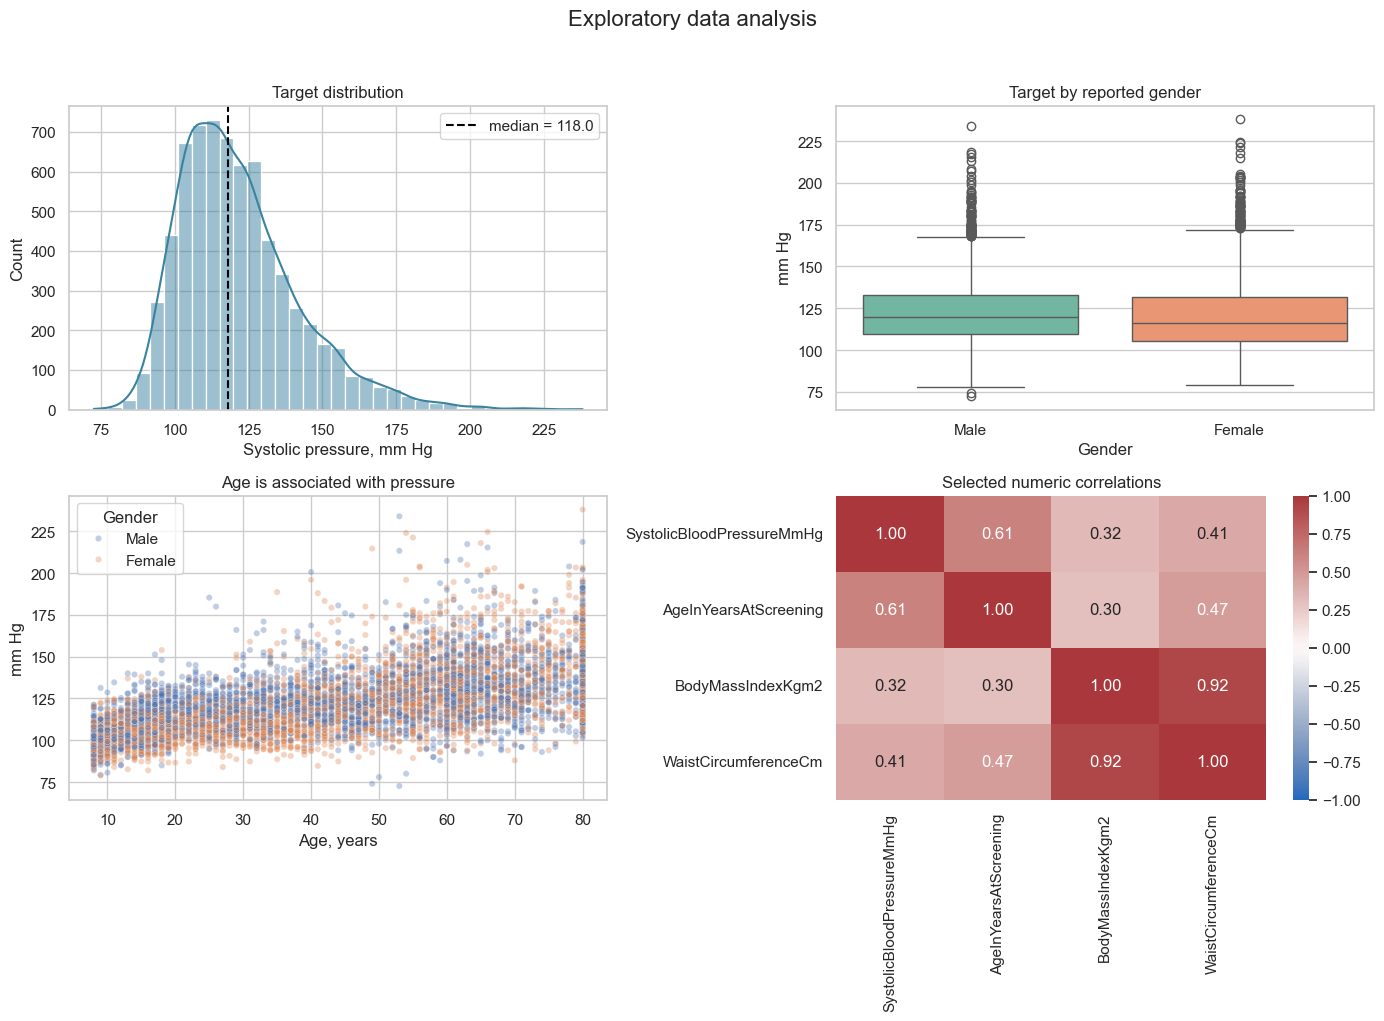

In [3]:
eda = df.loc[df[TARGET].notna(), [TARGET, 'AgeInYearsAtScreening', 'Gender', 'BodyMassIndexKgm2', 'WaistCircumferenceCm']].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(eda[TARGET], bins=35, kde=True, ax=axes[0, 0], color='#3B82A0')
axes[0, 0].axvline(eda[TARGET].median(), color='black', linestyle='--', label=f'median = {eda[TARGET].median():.1f}')
axes[0, 0].set(title='Target distribution', xlabel='Systolic pressure, mm Hg')
axes[0, 0].legend()

sns.boxplot(data=eda, x='Gender', y=TARGET, hue='Gender', legend=False, palette='Set2', ax=axes[0, 1])
axes[0, 1].set(title='Target by reported gender', xlabel='Gender', ylabel='mm Hg')

sns.scatterplot(data=eda, x='AgeInYearsAtScreening', y=TARGET, hue='Gender', alpha=.35, s=20, ax=axes[1, 0])
axes[1, 0].set(title='Age is associated with pressure', xlabel='Age, years', ylabel='mm Hg')

corr_columns = [TARGET, 'AgeInYearsAtScreening', 'BodyMassIndexKgm2', 'WaistCircumferenceCm']
sns.heatmap(eda[corr_columns].corr(), annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Selected numeric correlations')
fig.suptitle('Exploratory data analysis', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 4. Сценарий предсказания и отбор признаков

Я моделирую давление пациента на скрининговом визите по демографическим сведениям, антропометрии, ответам анкеты, привычкам, активности и обычным лабораторным показателям. Использую только 21 заранее обоснованный признак с понятным смыслом и приемлемой доступностью, а не все 193 столбца.

SEQN исключён как идентификатор. Намеренно исключён и DiastolicBloodPressureMmHg: хотя он коррелирует с целью, он получается в ходе того же измерения давления и дал бы модели недоступную в реальном сценарии информацию. Это утечка цели. Сильно разреженные и узкоспециальные вопросы также не используются.

Пропуски не удаляются построчно: это заметно уменьшило бы выборку и могло бы сместить её состав. Внутри каждого фолда и после разделения на train/test числовые пропуски заменяются медианой с индикатором пропуска, категориальные - наиболее частой категорией. Значит, статистики предобработки не используют тестовые строки.

,feature,type,missing_%,unique_non_missing
0,AgeInYearsAtScreening,numeric,0.0,73
1,Gender,categorical,0.0,2
2,RacehispanicOrigin,categorical,0.0,5
3,BodyMassIndexKgm2,numeric,1.2,431
4,WeightKg,numeric,1.0,1199
5,StandingHeightCm,numeric,1.0,692
6,WaistCircumferenceCm,numeric,4.3,937
7,GeneralHealthCondition,categorical,14.6,5
8,DoctorToldYouHaveDiabetes,categorical,0.1,3
9,SmokedAtLeast100CigarettesInLife,numeric,21.8,2


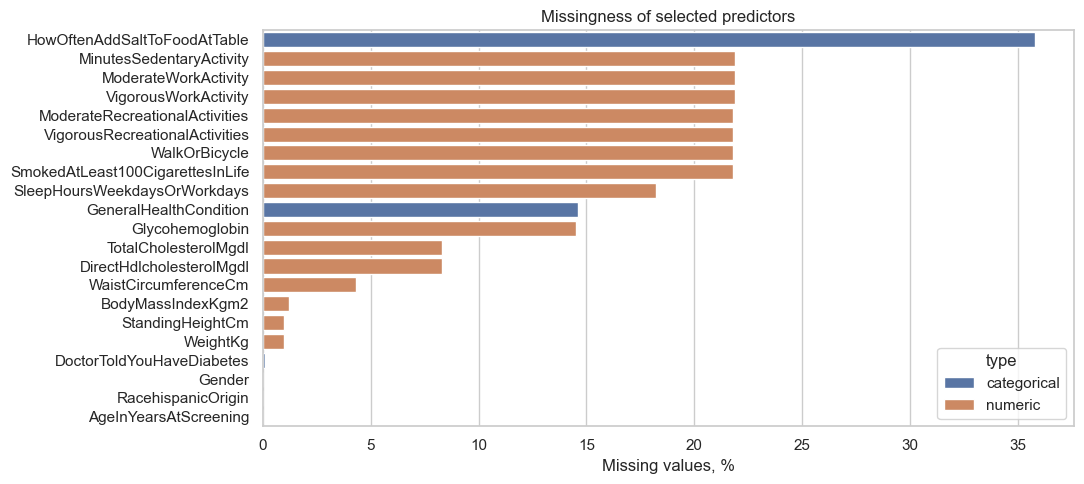

In [4]:
features = [
    'AgeInYearsAtScreening', 'Gender', 'RacehispanicOrigin',
    'BodyMassIndexKgm2', 'WeightKg', 'StandingHeightCm', 'WaistCircumferenceCm',
    'GeneralHealthCondition', 'DoctorToldYouHaveDiabetes',
    'SmokedAtLeast100CigarettesInLife', 'SleepHoursWeekdaysOrWorkdays',
    'HowOftenAddSaltToFoodAtTable',
    'VigorousWorkActivity', 'ModerateWorkActivity', 'WalkOrBicycle',
    'VigorousRecreationalActivities', 'ModerateRecreationalActivities',
    'MinutesSedentaryActivity', 'TotalCholesterolMgdl',
    'DirectHdlcholesterolMgdl', 'Glycohemoglobin'
]
assert not set(features).intersection({TARGET, 'SEQN', 'DiastolicBloodPressureMmHg'})

model_df = df.loc[df[TARGET].notna(), features + [TARGET]].copy()
X = model_df[features]
y = model_df[TARGET]
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = [feature for feature in features if feature not in numeric_features]

feature_overview = pd.DataFrame({'feature': features, 'type': ['numeric' if f in numeric_features else 'categorical' for f in features], 'missing_%': X[features].isna().mean().mul(100).round(1).values, 'unique_non_missing': X[features].nunique(dropna=True).values})
display(feature_overview)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=feature_overview.sort_values('missing_%', ascending=False), x='missing_%', y='feature', hue='type', dodge=False, ax=ax)
ax.set(title='Missingness of selected predictors', xlabel='Missing values, %', ylabel='')
plt.tight_layout()
plt.show()

## 5. Разделение данных, предобработка и выбор модели

Сначала откладываю 20% наблюдений как тестовые. Разделение стратифицировано по децилям давления, чтобы оба поднабора представляли весь диапазон цели. Все решения о модели принимаются по пятикратной кросс-валидации только на остальных 80%.

Для ориентира использую медианный прогноз и линейную Ridge-регрессию. Основная модель - ExtraTreesRegressor: ансамбль многих деревьев решений. Для каждого дерева используются случайные подмножества признаков и случайные пороги, затем выбирается удачное разбиение; итоговый прогноз - среднее предсказаний всех деревьев. Усреднение снижает дисперсию, а деревья моделируют нелинейности и взаимодействия, например разный эффект возраста при разной антропометрии, без предположения о линейной зависимости.

Гиперпараметры заданы до итоговой оценки: 300 деревьев стабилизируют усреднение, min_samples_leaf=4 сдерживает слишком глубокие листья, max_features=0.8 поддерживает разнообразие деревьев. Extra Trees выбирается только если улучшает CV-ошибку относительно ориентиров.

In [5]:
strata = pd.qcut(y, q=10, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strata)
print(f'Train: {X_train.shape[0]:,} rows; test: {X_test.shape[0]:,} rows')

numeric_linear = Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)), ('scaler', StandardScaler())])
numeric_tree = SimpleImputer(strategy='median', add_indicator=True)
categorical = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('one_hot', OneHotEncoder(handle_unknown='ignore'))])

linear_preprocessor = ColumnTransformer([('num', numeric_linear, numeric_features), ('cat', categorical, categorical_features)])
tree_preprocessor = ColumnTransformer([('num', numeric_tree, numeric_features), ('cat', categorical, categorical_features)])

candidates = {
    'Median baseline': DummyRegressor(strategy='median'),
    'Ridge': Pipeline([('preprocess', linear_preprocessor), ('model', Ridge(alpha=10.0))]),
    'Extra Trees': Pipeline([('preprocess', tree_preprocessor), ('model', ExtraTreesRegressor(n_estimators=300, min_samples_leaf=4, max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1))]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error', 'R2': 'r2'}
cv_rows = []
for name, estimator in candidates.items():
    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({'model': name, 'CV RMSE, mm Hg': -scores['test_RMSE'].mean(), 'CV MAE, mm Hg': -scores['test_MAE'].mean(), 'CV R2': scores['test_R2'].mean(), 'CV RMSE SD': scores['test_RMSE'].std()})

cv_results = pd.DataFrame(cv_rows).sort_values('CV RMSE, mm Hg').reset_index(drop=True)
display(cv_results.round(3))
selected_name = cv_results.loc[0, 'model']
print(f'Selected from training-only CV: {selected_name}')

Train: 5,476 rows; test: 1,370 rows


,model,"CV RMSE, mm Hg","CV MAE, mm Hg",CV R2,CV RMSE SD
0,Extra Trees,15.274,11.096,0.432,0.221
1,Ridge,15.559,11.457,0.411,0.257
2,Median baseline,20.649,15.457,-0.037,0.463


Selected from training-only CV: Extra Trees


## 6. Финальная оценка на ранее не использованном тесте

Выбираю модель с наименьшим средним CV RMSE, заново обучаю её на всей обучающей выборке и оцениваю один раз на тестовых строках. MAE показывает типичную абсолютную ошибку в мм рт. ст.; RMSE сильнее штрафует крупные ошибки; R² - доля вариации давления, объяснённая моделью по сравнению с тестовым средним. Метрики описывают предсказательное качество, а не причинные эффекты признаков.

,model,"test MAE, mm Hg","test RMSE, mm Hg",test R2
0,Extra Trees,11.176,15.478,0.432


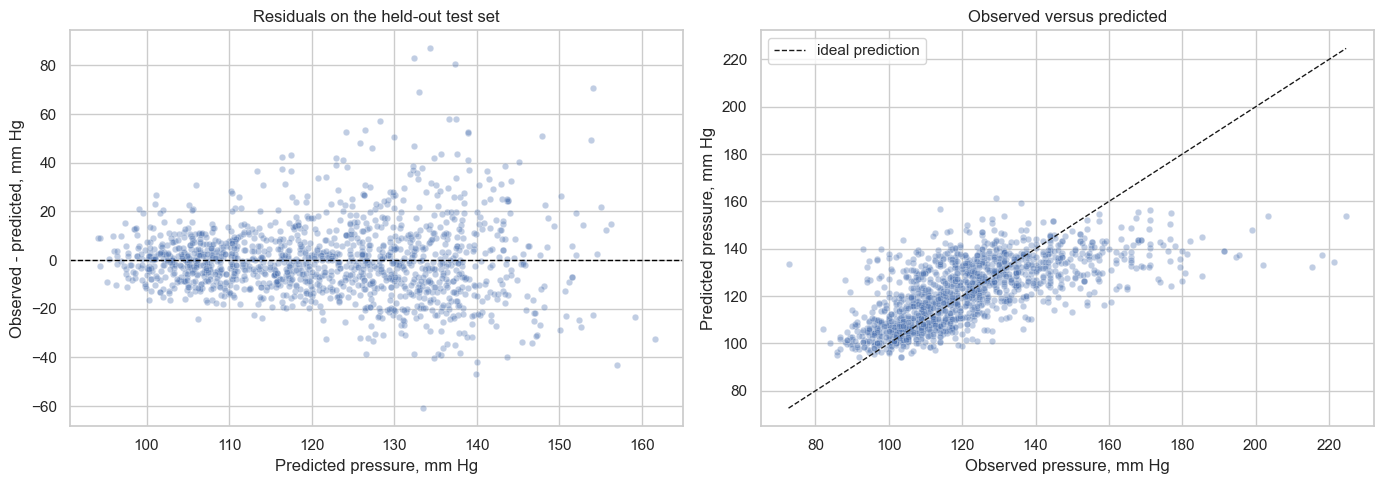

In [6]:
final_model = candidates[selected_name]
final_model.fit(X_train, y_train)
test_prediction = final_model.predict(X_test)

test_metrics = pd.DataFrame([{'model': selected_name, 'test MAE, mm Hg': mean_absolute_error(y_test, test_prediction), 'test RMSE, mm Hg': mean_squared_error(y_test, test_prediction) ** 0.5, 'test R2': r2_score(y_test, test_prediction)}])
display(test_metrics.round(3))

residuals = y_test - test_prediction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=test_prediction, y=residuals, alpha=.35, s=22, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set(title='Residuals on the held-out test set', xlabel='Predicted pressure, mm Hg', ylabel='Observed - predicted, mm Hg')

sns.scatterplot(x=y_test, y=test_prediction, alpha=.35, s=22, ax=axes[1])
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[1].plot(limits, limits, 'k--', linewidth=1, label='ideal prediction')
axes[1].set(title='Observed versus predicted', xlabel='Observed pressure, mm Hg', ylabel='Predicted pressure, mm Hg')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Интерпретация и ограничения

Для выбранного ансамбля приведена impurity-based importance признаков после предобработки. Она показывает, какие преобразованные признаки чаще уменьшали разброс цели в деревьях. Это не причинная интерпретация и может распределять важность между коррелирующими показателями, например весом, ИМТ и окружностью талии.

Ограничения решения: NHANES здесь используется как поперечная выборка без учёта survey weights; часть входов самоотчётная и имеет пропуски; возраст 80 и выше закодирован как 80; измерение давления вариабельно даже при повторных измерениях. Поэтому модель - воспроизводимый прогнозный пример, но не клинический инструмент и не основание для медицинских решений.

,transformed_feature,importance
0,num__AgeInYearsAtScreening,0.4078
22,num__missingindicator_VigorousWorkActivity,0.1073
2,num__WeightKg,0.0389
4,num__WaistCircumferenceCm,0.0306
1,num__BodyMassIndexKgm2,0.0247
13,num__TotalCholesterolMgdl,0.0227
3,num__StandingHeightCm,0.0212
34,cat__RacehispanicOrigin_Non-Hispanic Black,0.0197
15,num__Glycohemoglobin,0.0168
14,num__DirectHdlcholesterolMgdl,0.0160


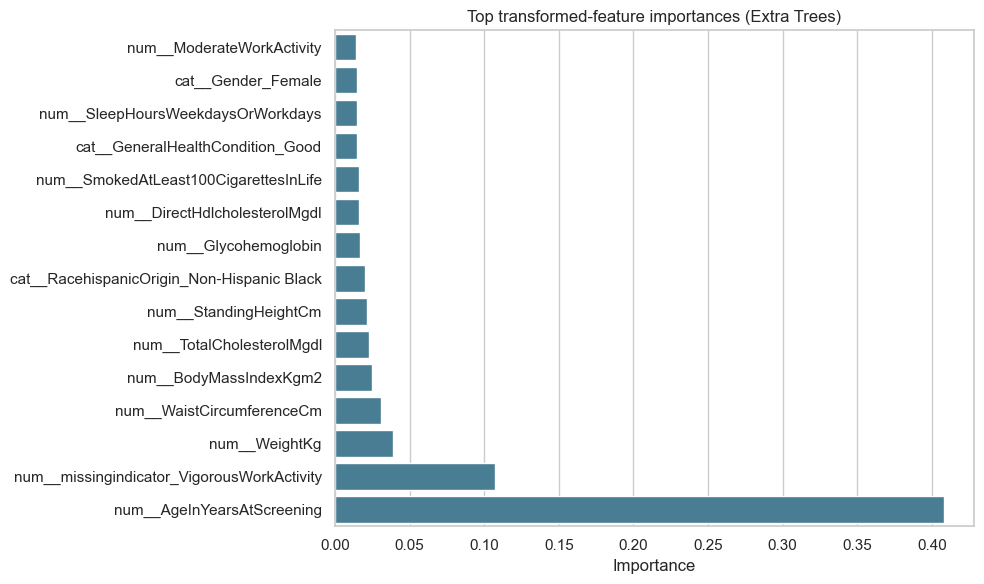

**Conclusion.** The selected model is **Extra Trees**. On the untouched test set it achieved **MAE = 11.18 mm Hg**, **RMSE = 15.48 mm Hg**, and **R² = 0.432**. The entire preprocessing and fitting sequence is inside the pipeline, so cross-validation and test evaluation use the same leak-resistant transformations.

In [7]:
if selected_name == 'Extra Trees':
    transformed_names = final_model.named_steps['preprocess'].get_feature_names_out()
    importances = pd.DataFrame({'transformed_feature': transformed_names, 'importance': final_model.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False)
    display(importances.head(15).round(4))

    fig, ax = plt.subplots(figsize=(10, 6))
    top = importances.head(15).sort_values('importance')
    sns.barplot(data=top, x='importance', y='transformed_feature', color='#3B82A0', ax=ax)
    ax.set(title='Top transformed-feature importances (Extra Trees)', xlabel='Importance', ylabel='')
    plt.tight_layout()
    plt.show()
else:
    print('The selected model is not tree-based; no tree feature importances are reported.')

display(Markdown(f'''**Conclusion.** The selected model is **{selected_name}**. On the untouched test set it achieved **MAE = {test_metrics.loc[0, 'test MAE, mm Hg']:.2f} mm Hg**, **RMSE = {test_metrics.loc[0, 'test RMSE, mm Hg']:.2f} mm Hg**, and **R² = {test_metrics.loc[0, 'test R2']:.3f}**. The entire preprocessing and fitting sequence is inside the pipeline, so cross-validation and test evaluation use the same leak-resistant transformations.'''))

## Воспроизводимость

Из корня репозитория создайте окружение, установите зависимости из ML/requirements.txt и запустите Jupyter Lab. Затем откройте ML/blood_pressure_regression.ipynb и выберите Run All Cells. Во всех случайных операциях указан seed, а исходные CSV версионируются в ML/data.